# Núcleo 3 — Simulador de sensibilidad de la coparticipación

Dado un shock porcentual en la recaudación tributaria nacional coparticipable, este
notebook calcula el impacto resultante en pesos para cada provincia (con foco en
Córdoba), usando `scripts/simulator.py` y los coeficientes de Ley 23.548 relevados en
el Núcleo 2.

**Supuestos del simulador** (documentados en detalle en el docstring de
`scripts/simulator.py` y en `docs/methodology.md`):
1. `recaudacion_base` es la masa coparticipable TOTAL (incluye lo que retiene la
   Nación y el Fondo ATN), no solo lo que reciben las provincias.
2. Se usan únicamente los coeficientes de Ley 23.548 -- **no** se incluye la
   compensación del Consenso Fiscal (Ley 27.429), porque es un monto históricamente
   fijo en pesos, no una proporción de la recaudación corriente.
3. Los adelantos de coparticipación (p. ej., Decreto 219/2026) son una **partida
   aparte** (anticipos a cuenta) -- no cambian el coeficiente de reparto, así que no
   se modelan acá.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
sys.path.insert(0, str(BASE_DIR / "scripts"))

from simulator import simular_shock
from coeficientes_ley23548 import COEFICIENTES_COPARTICIPACION

COLOR_NEGATIVO = "#e34948"
COLOR_POSITIVO = "#2a78d6"
COLOR_CORDOBA_BORDE = "#0b0b0b"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

suma_coeficientes_provincias = sum(COEFICIENTES_COPARTICIPACION.values())
print(f"Suma de los 24 coeficientes (participación de las provincias en la masa coparticipable total): {suma_coeficientes_provincias:.4f}")

Suma de los 24 coeficientes (participación de las provincias en la masa coparticipable total): 0.5876


## 1. Caso de validación: caída de recaudación del primer cuatrimestre de 2026

El IARAF estimó que en el primer cuatrimestre de 2026 la recaudación tributaria
nacional cayó en términos reales unos **$5,1 billones**, de los cuales
**$1,4 billones** representaron menos coparticipación para las provincias.

**Cómo se arma esta validación** (siendo honestos sobre sus límites): no se consiguió,
por las mismas restricciones de acceso a internet de este entorno, una cifra oficial de
"masa coparticipable de referencia" para ese período específico. En cambio, se
construye una `recaudacion_base` propia a partir de datos reales que sí tenemos (la
coparticipación nominal 2025 del Núcleo 1), y se usa junto con la cifra de IARAF para
chequear **consistencia interna**, no una predicción totalmente a ciegas.

In [2]:
df_n1 = pd.read_csv(BASE_DIR / "data" / "processed" / "coparticipacion_real.csv")
total_2025 = df_n1[df_n1["anio"] == 2025]["monto_nominal"].sum() * 1e6  # el CSV está en millones de pesos

# Aproximación: un cuatrimestre = 4/12 del año. Es una aproximación declarada, no un dato real mensual.
recibido_provincias_4m = total_2025 * 4 / 12

# "Gross-up": lo que reciben las provincias es el `suma_coeficientes_provincias` de la masa total.
recaudacion_base_4m = recibido_provincias_4m / suma_coeficientes_provincias

print(f"Coparticipación nominal recibida por las 24 jurisdicciones en 2025: ${total_2025:,.0f}")
print(f"Aproximación a 4 meses: ${recibido_provincias_4m:,.0f}")
print(f"Masa coparticipable total estimada (4 meses): ${recaudacion_base_4m:,.0f}")

Coparticipación nominal recibida por las 24 jurisdicciones en 2025: $48,951,168,366,528
Aproximación a 4 meses: $16,317,056,122,176
Masa coparticipable total estimada (4 meses): $27,768,985,912,485


In [3]:
# Variación % que, aplicada a esta base, reproduce el impacto de $1,4 billones que reportó IARAF.
IMPACTO_OBJETIVO_IARAF = -1.4e12

variacion_implicita = IMPACTO_OBJETIVO_IARAF / suma_coeficientes_provincias / recaudacion_base_4m
print(f"Variación % de recaudación implícita: {variacion_implicita:.2%}")

resultado_validacion = simular_shock(variacion_implicita, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
print(f"Impacto total en provincias (modelo): ${resultado_validacion['total_impacto_provincias']:,.0f}")
print(f"Impacto reportado por IARAF:          ${IMPACTO_OBJETIVO_IARAF:,.0f}")

# Chequeo de consistencia independiente: ¿qué fracción de la caída TOTAL de recaudación
# (no solo la coparticipable) representa la masa coparticipable afectada?
CAIDA_TOTAL_RECAUDACION_IARAF = -5.1e12
monto_coparticipable_afectado = resultado_validacion["monto_total_afectado"]
tasa_coparticipabilidad_implicita = monto_coparticipable_afectado / CAIDA_TOTAL_RECAUDACION_IARAF
print(f"\nTasa de 'coparticipabilidad' implícita (masa coparticipable / caída total): {tasa_coparticipabilidad_implicita:.1%}")

Variación % de recaudación implícita: -8.58%
Impacto total en provincias (modelo): $-1,400,000,000,000
Impacto reportado por IARAF:          $-1,400,000,000,000

Tasa de 'coparticipabilidad' implícita (masa coparticipable / caída total): 46.7%


**Lectura de la validación**: por construcción, el modelo reproduce exactamente el
impacto de $1,4 billones que reportó IARAF (así se derivó la variación % implícita).
Eso *no* es una predicción ciega -- es una calibración. Lo que sí es una validación
genuina es que los dos números que salen de esa calibración son **plausibles**:

- Una caída real de recaudación coparticipable de ~8,6% en el período es un orden de
  magnitud razonable para un shock macro relevante, ni extremo ni trivial.
- La "tasa de coparticipabilidad" implícita (~46,7% de la caída total de recaudación
  afecta a la masa coparticipable) cae dentro del rango que suele citarse para
  Argentina (aproximadamente 40-50% de la recaudación nacional total es coparticipable
  bajo la Ley 23.548, el resto son impuestos no coparticipables como derechos de
  exportación, o regímenes con otro destino).

Si estos dos números hubieran salido, por ejemplo, con una tasa de coparticipabilidad
del 90% o del 5%, eso habría sido una señal de que algo en la `recaudacion_base`
estimada (o en la cifra de IARAF) no encaja -- no fue el caso acá. **Esta es la validación:
consistencia entre una fuente externa (IARAF) y datos propios del proyecto (Núcleo 1),
no una comparación contra una tercera fuente independiente de recaudación coparticipable
real de 2026**, que no se consiguió conseguir dadas las restricciones de acceso a
internet de este entorno.

## 2. Impacto por provincia en el caso de validación

¿Cómo se hubiera repartido ese impacto de $1,4 billones entre las 24 jurisdicciones?
¿Dónde queda Córdoba?

Impacto estimado para Córdoba: $-120,073,396,869 (unos $120.1 mil millones menos)


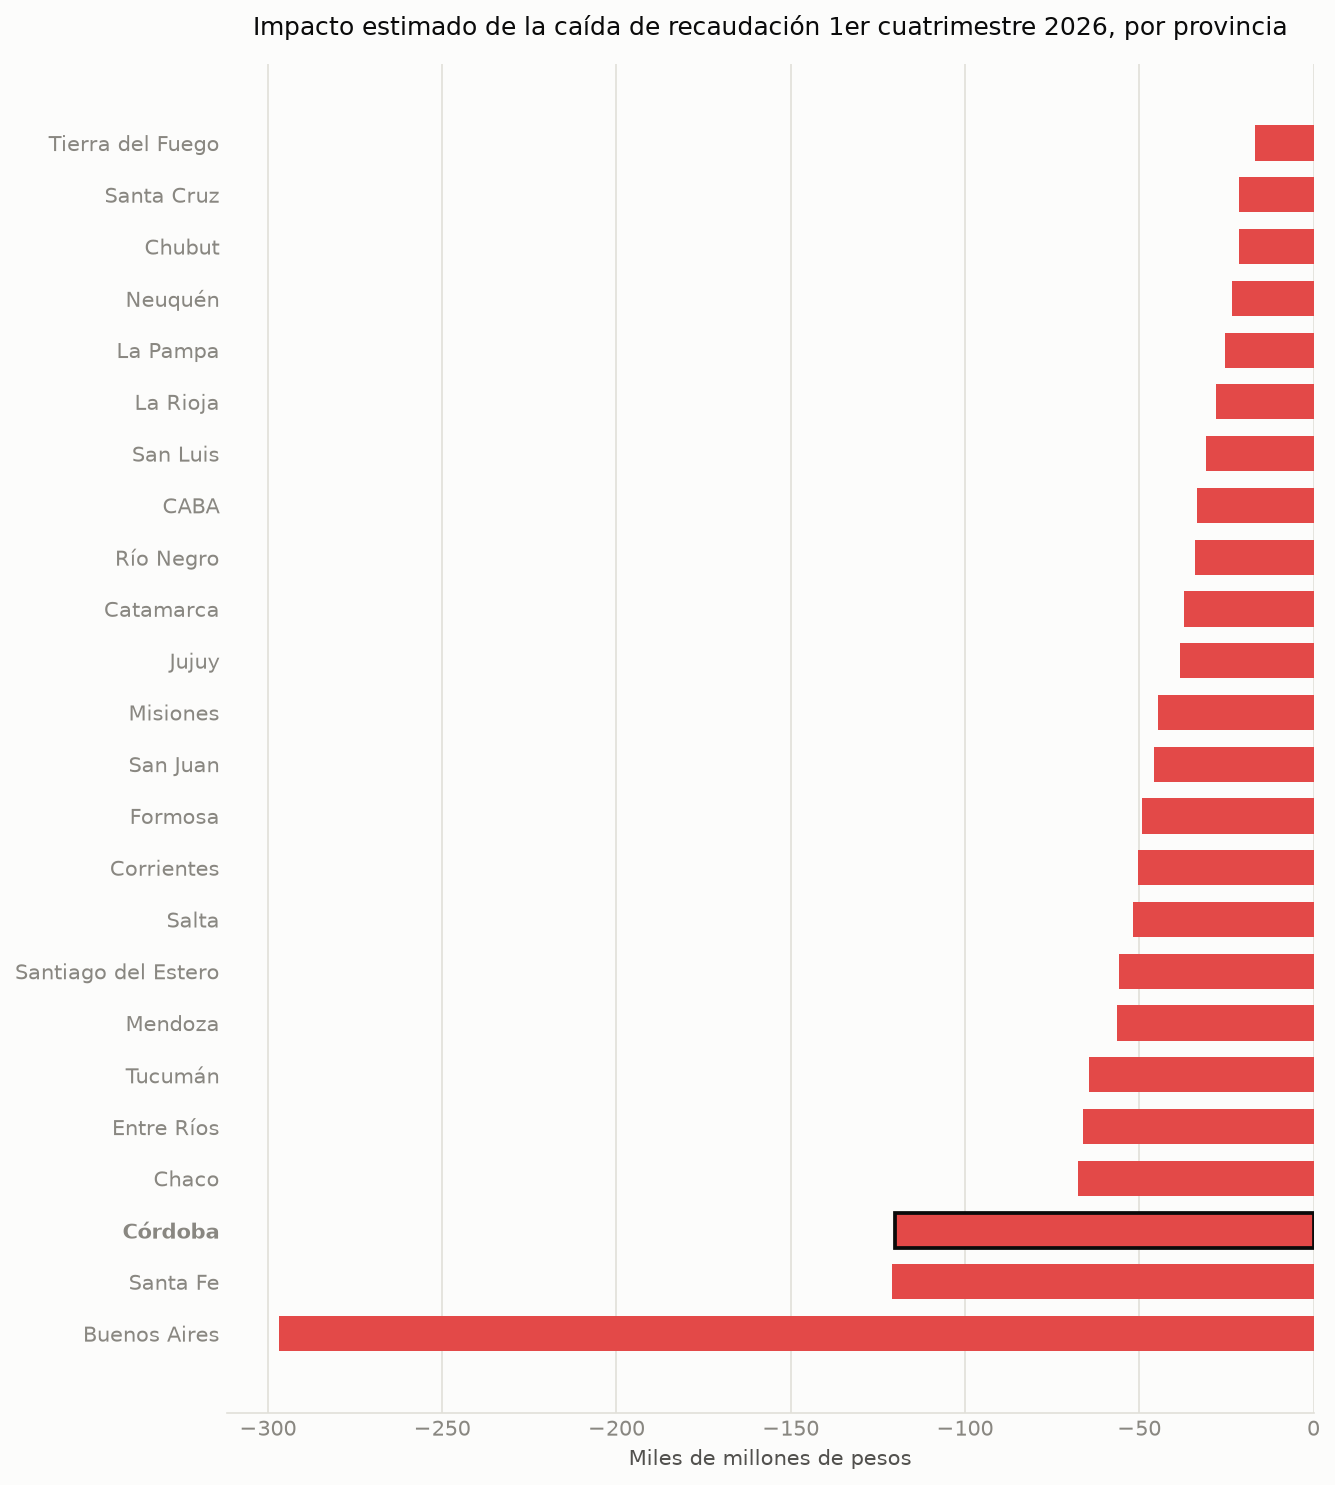

In [4]:
impacto_df = pd.DataFrame(resultado_validacion["por_provincia"]).sort_values("impacto_pesos")

cordoba_impacto = impacto_df[impacto_df["provincia"] == "Córdoba"]["impacto_pesos"].iloc[0]
print(f"Impacto estimado para Córdoba: ${cordoba_impacto:,.0f} (unos ${abs(cordoba_impacto)/1e9:,.1f} mil millones menos)")

fig, ax = plt.subplots(figsize=(9, 10), dpi=150)
bordes = [COLOR_CORDOBA_BORDE if p == "Córdoba" else "none" for p in impacto_df["provincia"]]
grosor = [1.8 if p == "Córdoba" else 0 for p in impacto_df["provincia"]]
ax.barh(impacto_df["provincia"], impacto_df["impacto_pesos"] / 1e9, color=COLOR_NEGATIVO, edgecolor=bordes, linewidth=grosor, height=0.68)

ax.set_title("Impacto estimado de la caída de recaudación 1er cuatrimestre 2026, por provincia", fontsize=12, color=INK_PRIMARY, pad=14)
ax.set_xlabel("Miles de millones de pesos", fontsize=10)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
for label in ax.get_yticklabels():
    if label.get_text() == "Córdoba":
        label.set_fontweight("bold")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "simulador_validacion_1cuatrimestre2026.png", dpi=300, facecolor=SURFACE)
plt.show()

## 3. Ejemplos de uso: escenarios de caída real de 5%, 10% y 15%

Usando la misma `recaudacion_base` (masa coparticipable estimada para un cuatrimestre),
¿cómo cambiaría el impacto sobre Córdoba ante distintas magnitudes de shock?

In [5]:
escenarios = [-0.05, -0.10, -0.15]
filas = []
for variacion in escenarios:
    resultado = simular_shock(variacion, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
    cordoba = [p for p in resultado["por_provincia"] if p["provincia"] == "Córdoba"][0]
    filas.append({
        "escenario": f"{variacion:.0%}",
        "impacto_total_provincias": resultado["total_impacto_provincias"],
        "impacto_cordoba": cordoba["impacto_pesos"],
    })

tabla_escenarios = pd.DataFrame(filas)
tabla_escenarios["impacto_total_provincias"] = tabla_escenarios["impacto_total_provincias"].map(lambda x: f"${x/1e9:,.1f} mil M")
tabla_escenarios["impacto_cordoba"] = tabla_escenarios["impacto_cordoba"].map(lambda x: f"${x/1e9:,.1f} mil M")
tabla_escenarios

,escenario,impacto_total_provincias,impacto_cordoba
0,-5%,$-815.9 mil M,$-70.0 mil M
1,-10%,"$-1,631.7 mil M",$-139.9 mil M
2,-15%,"$-2,447.6 mil M",$-209.9 mil M


## 4. Simulador interactivo

Deslizá para elegir una caída (o suba) real de recaudación y ver el impacto resultante
en Córdoba y en el total de provincias, en vivo.

In [6]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.FloatSlider(
    value=-8.6, min=-30, max=30, step=0.5,
    description="Variación %:", continuous_update=False,
    style={"description_width": "initial"}, layout=widgets.Layout(width="500px"),
)
salida = widgets.Output()


def actualizar(change):
    with salida:
        salida.clear_output(wait=True)
        variacion = slider.value / 100
        resultado = simular_shock(variacion, recaudacion_base_4m, COEFICIENTES_COPARTICIPACION)
        cordoba = [p for p in resultado["por_provincia"] if p["provincia"] == "Córdoba"][0]

        print(f"Variación de recaudación coparticipable: {variacion:+.1%}")
        print(f"Impacto total en las 24 provincias: ${resultado['total_impacto_provincias']/1e9:,.1f} mil millones")
        print(f"Impacto en Córdoba: ${cordoba['impacto_pesos']/1e9:,.1f} mil millones")

        fig, ax = plt.subplots(figsize=(6, 3.2), dpi=120)
        color = COLOR_NEGATIVO if cordoba["impacto_pesos"] < 0 else COLOR_POSITIVO
        ax.barh(["Córdoba"], [cordoba["impacto_pesos"] / 1e9], color=color, height=0.5)
        ax.axvline(0, color=GRID_COLOR, linewidth=1)
        ax.set_xlabel("Miles de millones de pesos")
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis="both", length=0)
        fig.tight_layout()
        plt.show()


slider.observe(actualizar, names="value")
display(slider, salida)
actualizar(None)

FloatSlider(value=-8.6, continuous_update=False, description='Variación %:', layout=Layout(width='500px'), max…

Output()

## 5. Conclusiones

- El simulador (`scripts/simulator.py`) es una función pura, documentada y con 9 tests
  automáticos (`scripts/test_simulator.py`), que reparte un shock de recaudación entre
  provincias según los coeficientes de la Ley 23.548.
- El caso de validación contra la caída de recaudación del primer cuatrimestre de 2026
  reportada por IARAF arrojó una tasa de coparticipabilidad implícita (~46,7%) y una
  variación real implícita (~-8,6%) consistentes con lo esperable -- no es una
  predicción ciega verificada contra una fuente independiente, sino un chequeo de
  consistencia entre la cifra de IARAF y los datos reales del Núcleo 1.
- Para un shock de recaudación real del orden del observado en el primer cuatrimestre
  de 2026, Córdoba pierde del orden de $120 mil millones de pesos de coparticipación.